# Customer Support Tickets — EDA

Датасет: [`Tobi-Bueck/customer-support-tickets`](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets)  
Задача: классификация по **queue** (52 класса), **priority** (5 классов), **type** (5 классов).  
Оценочная метрика: `Score = 0.70·MacroF1(queue) + 0.15·Acc(priority) + 0.15·Acc(type)`


## 0. Импорты и конфигурация

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from datasets import load_dataset

# --- пути ---
ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

# --- стиль ---
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

DATASET_ID = 'Tobi-Bueck/customer-support-tickets'
print(f'ROOT: {ROOT}')
print(f'PLOTS_DIR: {PLOTS_DIR}')

ROOT: /Users/semenisaev/NLP_project_1
PLOTS_DIR: /Users/semenisaev/NLP_project_1/plots


## 1. Загрузка датасета

In [2]:
print(f'Загружаем датасет {DATASET_ID} ...')
ds = load_dataset(DATASET_ID)
df = ds['train'].to_pandas()
print(f'Полный датасет: {df.shape[0]:,} строк × {df.shape[1]} колонок')
print('Колонки:', df.columns.tolist())

Загружаем датасет Tobi-Bueck/customer-support-tickets ...
Полный датасет: 61,765 строк × 16 колонок
Колонки: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


## 2. Фиксированный сплит по индексам

Файлы `data/train_idx.txt`, `data/val_idx.txt`, `data/test_idx.txt` уже зафиксированы  
(seed=42, train=49 412, val=6 176, test=6 177, без пересечений по `subject+body`).

In [3]:
import hashlib

def read_idx(path):
    return np.loadtxt(path, dtype=np.int64)

train_idx = read_idx(DATA_DIR / 'train_idx.txt')
val_idx   = read_idx(DATA_DIR / 'val_idx.txt')
test_idx  = read_idx(DATA_DIR / 'test_idx.txt')

df_train = df.iloc[train_idx].reset_index(drop=True).copy()
df_val   = df.iloc[val_idx].reset_index(drop=True).copy()
df_test  = df.iloc[test_idx].reset_index(drop=True).copy()

# заполняем Unknown для type
for d in (df_train, df_val, df_test):
    d['type'] = d['type'].fillna('Unknown')

splits = {'train': df_train, 'val': df_val, 'test': df_test}

print('Размеры сплитов:')
for name, d in splits.items():
    print(f'  {name}: {len(d):,}')

# Проверка пересечений по тексту
def md5(s):
    return hashlib.md5(s.encode('utf-8', errors='ignore')).hexdigest()

hashes = {}
for name, d in splits.items():
    txt = (d['subject'].fillna('') + '\n\n' + d['body'].fillna('')).astype(str)
    hashes[name] = set(txt.map(md5).tolist())

tv = len(hashes['train'] & hashes['val'])
tt = len(hashes['train'] & hashes['test'])
vt = len(hashes['val']   & hashes['test'])
print(f'\nПересечения текстов: train∩val={tv}, train∩test={tt}, val∩test={vt}')
if tv == tt == vt == 0:
    print('[OK] Межсплитовых текстовых дублей нет.')
else:
    print('[WARN] Есть текстовые дубли между сплитами!')

Размеры сплитов:
  train: 49,412
  val: 6,176
  test: 6,177

Пересечения текстов: train∩val=0, train∩test=0, val∩test=0
[OK] Межсплитовых текстовых дублей нет.


## 3. Первый взгляд на данные

In [4]:
print('=== df_train.head() ===')
df_train.head()

=== df_train.head() ===


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,None,None,None,None
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,None,None,None
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,None,None,None,None,None
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,None,None,None
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,None,None,None,None


In [5]:
print('=== Базовая статистика (train) ===')
df_train.describe(include='all')

=== Базовая статистика (train) ===


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,45144,49410,38893,49412,49412,49412,49412,22924.000000,38904,38857,38722,35212,22118,10580,4757,1981
unique,37709,42694,32168,5,52,5,2,NaN,189,323,543,746,868,820,664,460
top,Anfrage für Unterstützung,"Dear Customer Support, I am reporting a critic...","Hello, we sincerely apologize for the system c...",Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,15632,11354,18629,26799,NaN,7341,6945,7478,7944,5576,2097,396,137
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.478756,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.933647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Процент NaN / Unknown по колонкам

Процент NaN + Unknown (%) по колонкам и сплитам:


split,test,train,val
column,,,
body,0.00,0.00,0.00
language,0.00,0.00,0.00
priority,0.00,0.00,0.00
queue,0.00,0.00,0.00
subject,8.52,8.64,8.18
type,20.88,21.27,22.34


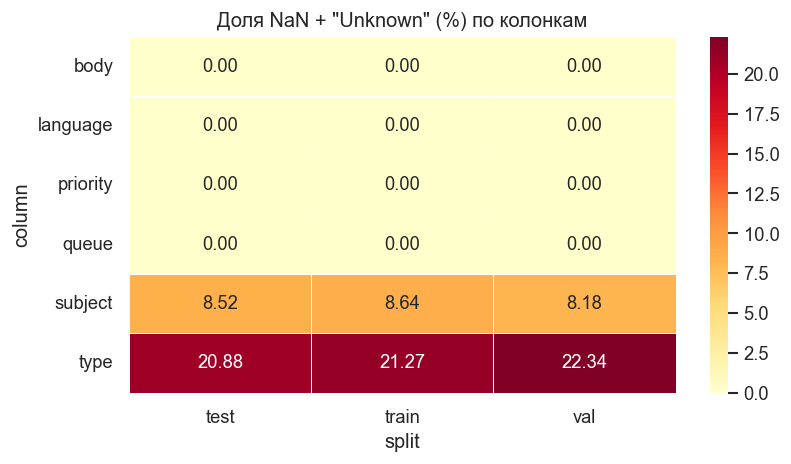

Сохранено: /Users/semenisaev/NLP_project_1/plots/nan_heatmap.png


In [6]:
TARGET_COLS = ['subject', 'body', 'queue', 'priority', 'type', 'language']

nan_rows = []
for split_name, d in splits.items():
    for col in TARGET_COLS:
        if col not in d.columns:
            pct = 100.0
        else:
            # считаем NaN + строку 'Unknown'
            pct_nan = d[col].isna().mean() * 100
            pct_unk = (d[col].astype(str).str.strip().str.lower() == 'unknown').mean() * 100
            pct = pct_nan + pct_unk
        nan_rows.append({'split': split_name, 'column': col, 'nan_or_unknown_%': round(pct, 2)})

nan_df = pd.DataFrame(nan_rows).pivot(index='column', columns='split', values='nan_or_unknown_%')
print('Процент NaN + Unknown (%) по колонкам и сплитам:')
display(nan_df)

# Тепловая карта
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(nan_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Доля NaN + "Unknown" (%) по колонкам')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'nan_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "nan_heatmap.png"}')

## 5. Распределение целевой переменной `queue` (52 класса)

### 5.1 Топ-20 классов

Уникальных классов queue (train): 41


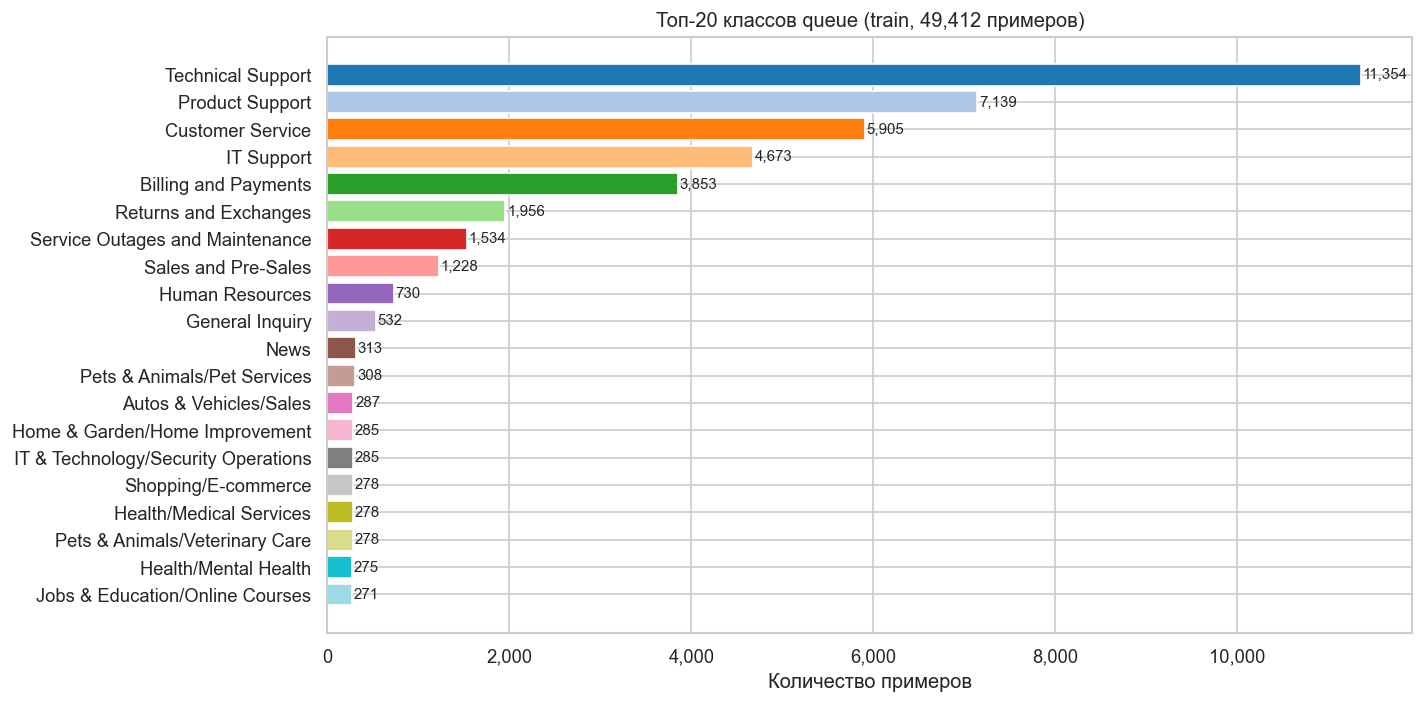

Сохранено: /Users/semenisaev/NLP_project_1/plots/queue_top20.png


In [7]:
vc_queue = df_train['queue'].value_counts()
print(f'Уникальных классов queue (train): {vc_queue.nunique()}')

TOP_N = 20
top20 = vc_queue.head(TOP_N)
tail   = vc_queue.iloc[TOP_N:]

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab20', TOP_N)
bars = ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])

for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Количество примеров')
ax.set_title(f'Топ-{TOP_N} классов queue (train, {len(df_train):,} примеров)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'queue_top20.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "queue_top20.png"}')

### 5.2 Хвост распределения (классы 21–52)

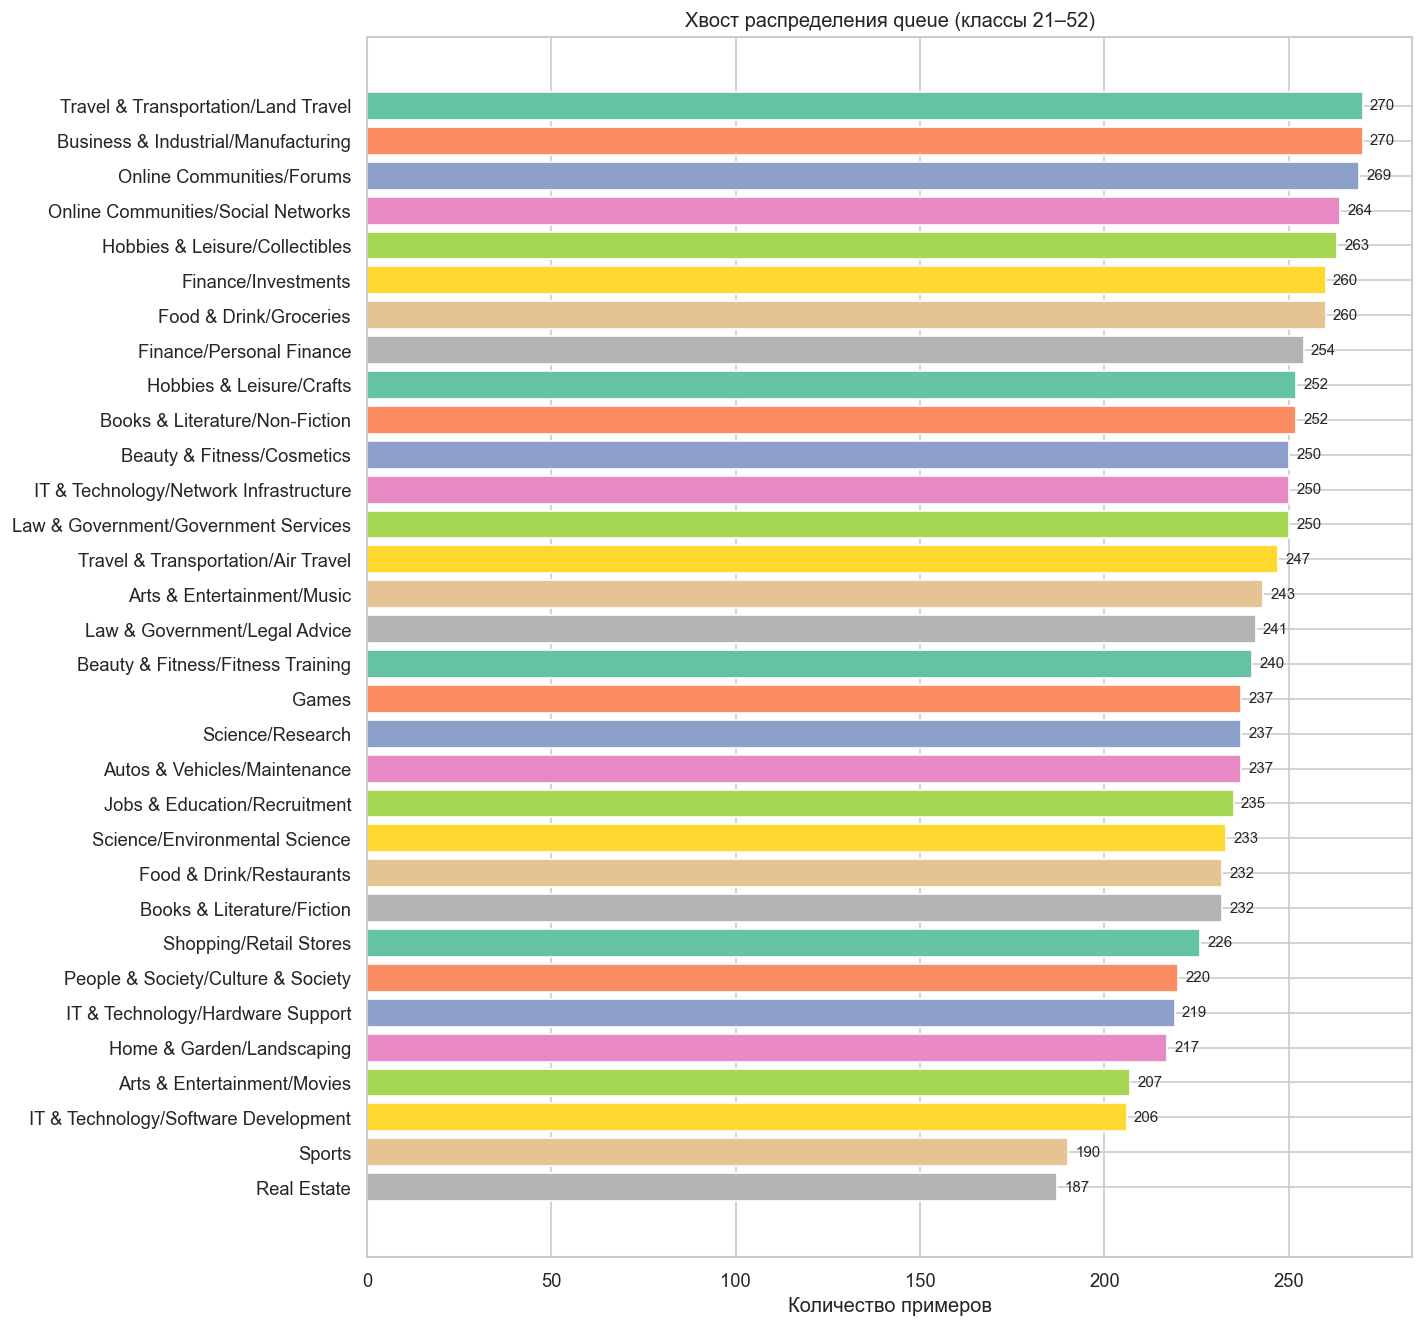

Сохранено: /Users/semenisaev/NLP_project_1/plots/queue_tail.png


In [8]:
fig, ax = plt.subplots(figsize=(12, max(4, len(tail) * 0.35)))
colors_tail = sns.color_palette('Set2', len(tail))
bars = ax.barh(tail.index[::-1], tail.values[::-1], color=colors_tail[::-1])

for bar, val in zip(bars, tail.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)

ax.set_xlabel('Количество примеров')
ax.set_title(f'Хвост распределения queue (классы {TOP_N+1}–{len(vc_queue)})')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'queue_tail.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "queue_tail.png"}')

### 5.3 Соотношение имбаланса классов queue

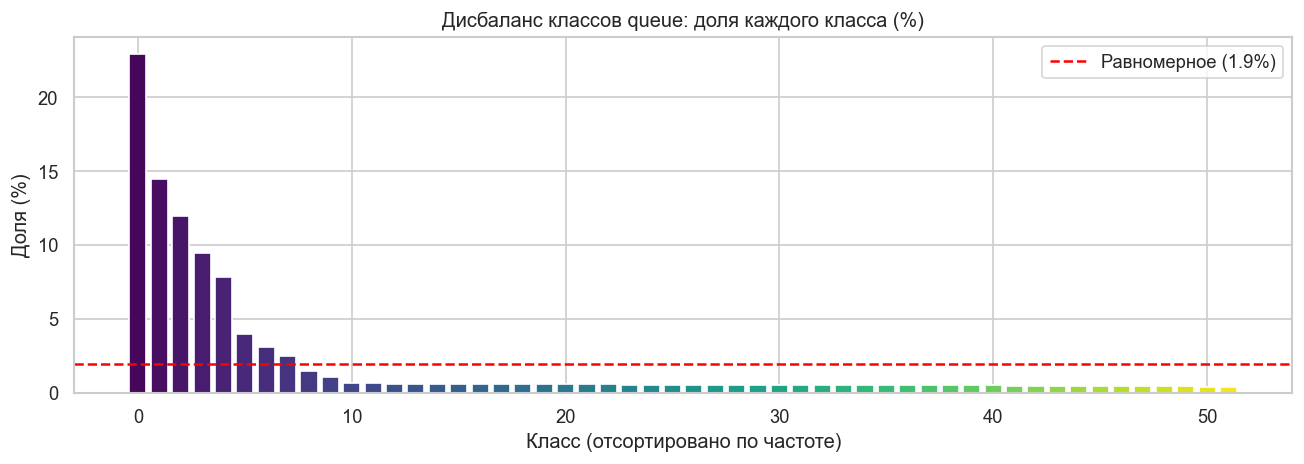


Max/min ratio: 60.7x
Сохранено: /Users/semenisaev/NLP_project_1/plots/queue_imbalance.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 4))
pct = (vc_queue / vc_queue.sum() * 100)
ax.bar(range(len(pct)), pct.values, color=sns.color_palette('viridis', len(pct)))
ax.set_xlabel('Класс (отсортировано по частоте)')
ax.set_ylabel('Доля (%)')
ax.set_title('Дисбаланс классов queue: доля каждого класса (%)')
ax.axhline(y=100/len(pct), color='red', linestyle='--', label=f'Равномерное ({100/len(pct):.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'queue_imbalance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\nMax/min ratio: {vc_queue.max()/vc_queue.min():.1f}x')
print(f'Сохранено: {PLOTS_DIR / "queue_imbalance.png"}')

## 6. Распределение `priority` (5 классов) и `type` (5 классов)

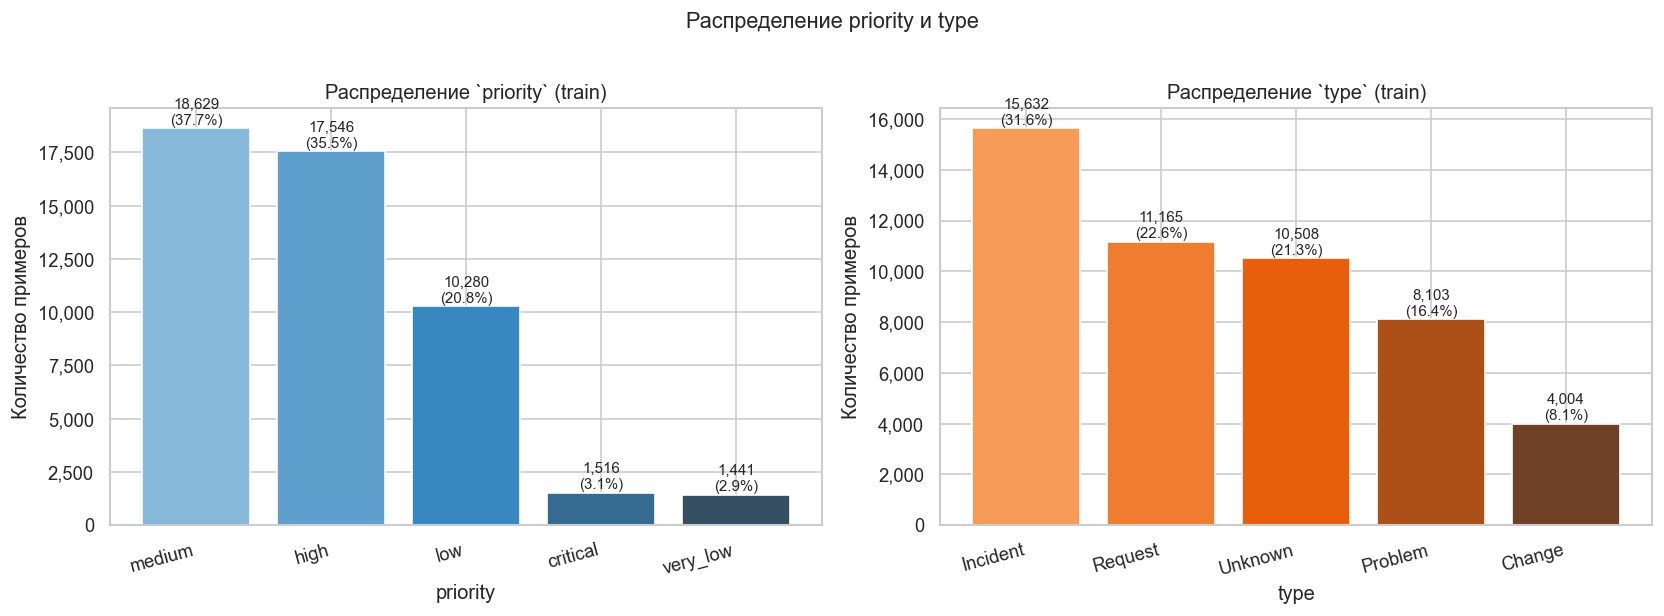

Сохранено: /Users/semenisaev/NLP_project_1/plots/priority_type_dist.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, palette in zip(axes, ['priority', 'type'], ['Blues_d', 'Oranges_d']):
    vc = df_train[col].fillna('Unknown').value_counts()
    colors = sns.color_palette(palette, len(vc))
    bars = ax.bar(vc.index, vc.values, color=colors)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}\n({val/len(df_train)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Распределение `{col}` (train)')
    ax.set_xlabel(col)
    ax.set_ylabel('Количество примеров')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

plt.suptitle('Распределение priority и type', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'priority_type_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "priority_type_dist.png"}')

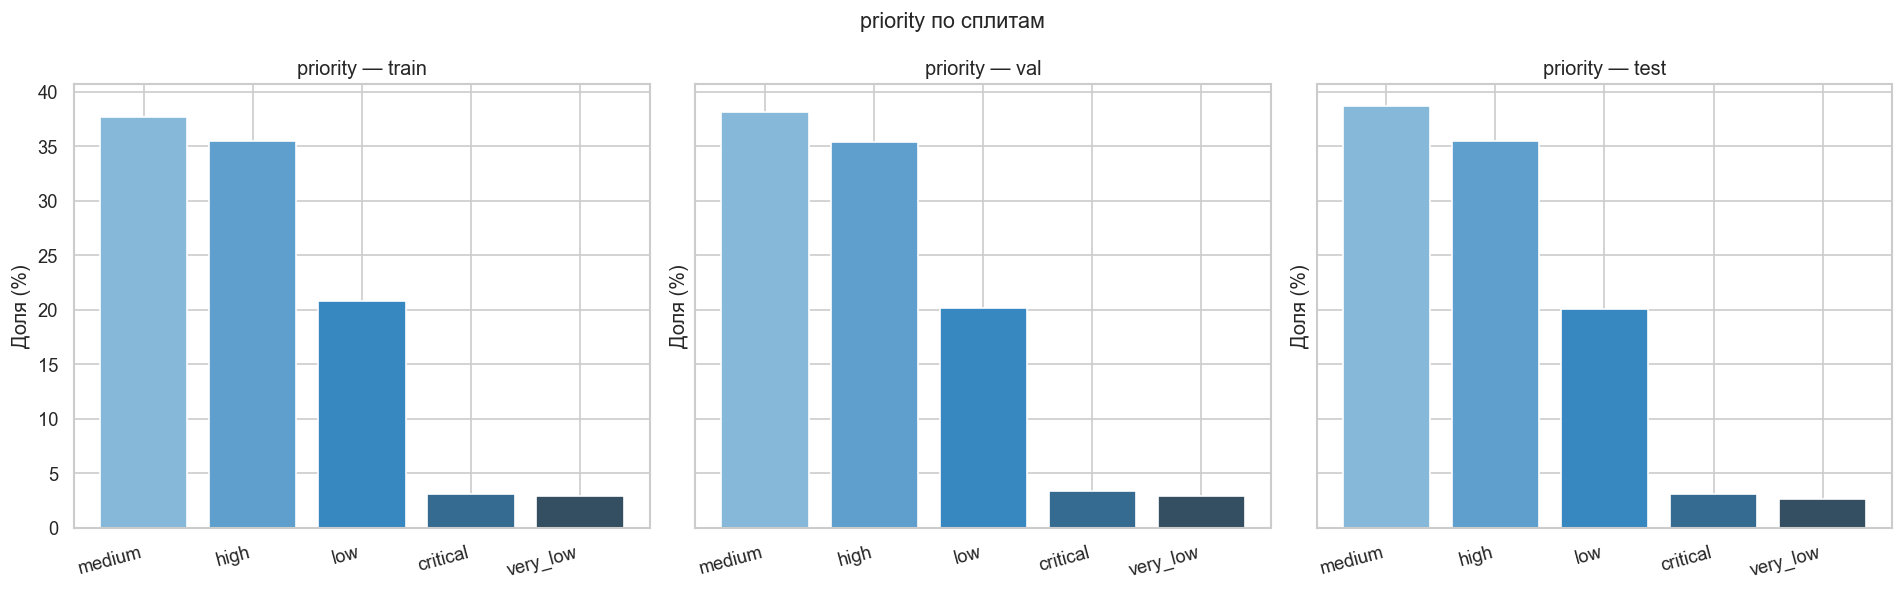

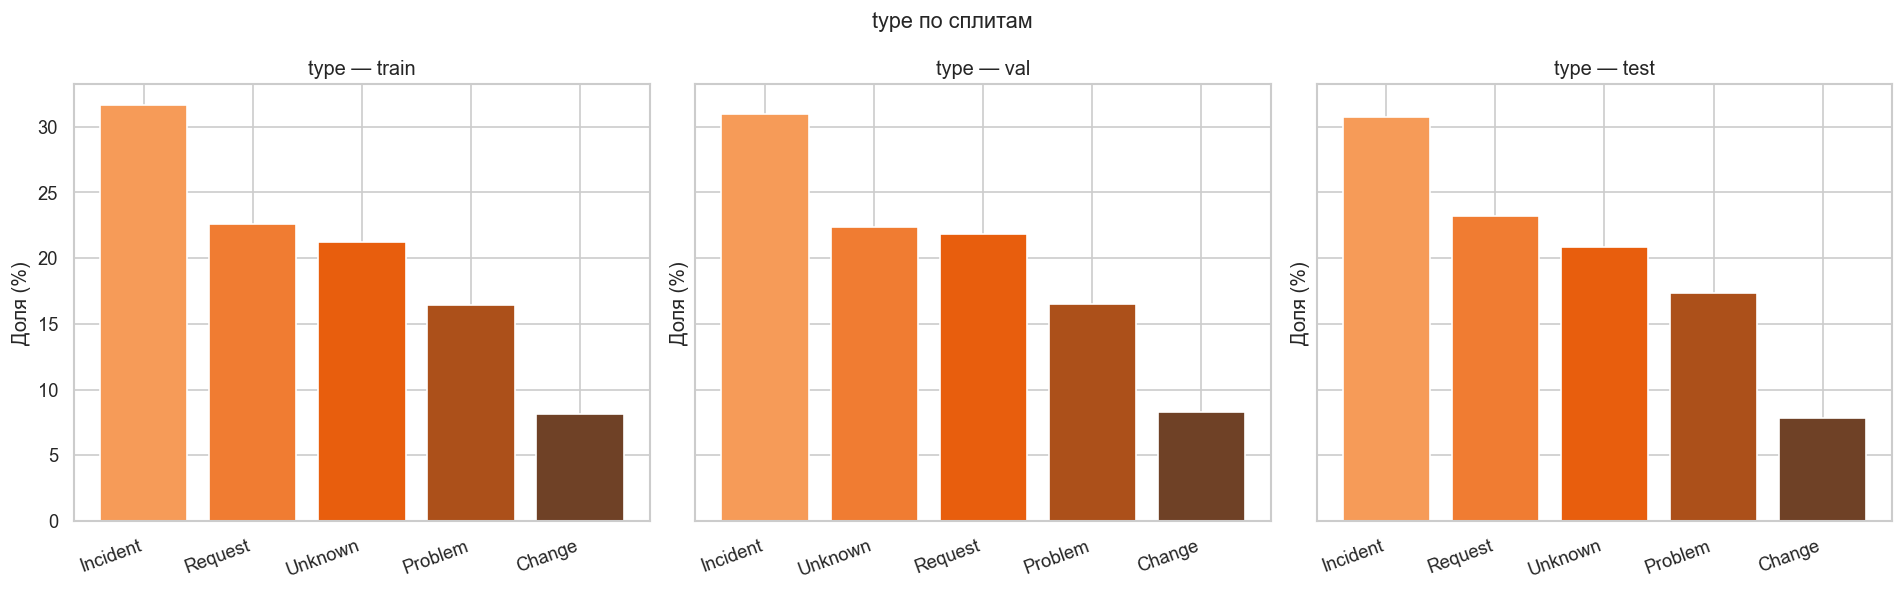

Сохранено: priority_splits.png, type_splits.png


In [11]:
# Сравнение по всем сплитам — priority
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (name, d) in zip(axes, splits.items()):
    vc = d['priority'].fillna('Unknown').value_counts(normalize=True) * 100
    ax.bar(vc.index, vc.values, color=sns.color_palette('Blues_d', len(vc)))
    ax.set_title(f'priority — {name}')
    ax.set_ylabel('Доля (%)')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
plt.suptitle('priority по сплитам', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'priority_splits.png', dpi=120, bbox_inches='tight')
plt.show()

# type по сплитам
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, (name, d) in zip(axes, splits.items()):
    vc = d['type'].fillna('Unknown').value_counts(normalize=True) * 100
    ax.bar(vc.index, vc.values, color=sns.color_palette('Oranges_d', len(vc)))
    ax.set_title(f'type — {name}')
    ax.set_ylabel('Доля (%)')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
plt.suptitle('type по сплитам', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'type_splits.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: priority_splits.png, type_splits.png')

## 7. Длины текстов в (whitespace-)токенах

Подсчёт через `str.split()` — быстрый прокси для числа слов/токенов.

In [12]:
# Вычисляем длины
for name, d in splits.items():
    d['_len_subject'] = d['subject'].fillna('').str.split().map(len)
    d['_len_body']    = d['body'].fillna('').str.split().map(len)
    d['_len_total']   = d['_len_subject'] + d['_len_body']

# Статистика перцентилей
pct_levels = [0, 25, 50, 75, 90, 95, 99, 100]
rows = []
for name, d in splits.items():
    for col in ['_len_subject', '_len_body', '_len_total']:
        row = {'split': name, 'field': col.replace('_len_', '')}
        for p in pct_levels:
            row[f'p{p}'] = int(np.percentile(d[col], p))
        row['mean'] = round(d[col].mean(), 1)
        rows.append(row)

pct_df = pd.DataFrame(rows).set_index(['split', 'field'])
print('Перцентили длин текстов (в словах):')
display(pct_df)

Перцентили длин текстов (в словах):


p0  p25  p50  p75  p90  p95  p99  p100  mean
split field                                                
train subject   0    4    5    7    8    9   12    77   5.1
      body      0   31   57   82   93  102  138   281  57.4
      total     1   37   62   87   99  108  143   283  62.4
val   subject   0    4    5    7    8    9   12    26   5.1
      body      2   32   57   82   93  102  136   235  57.6
      total     3   37   62   87   98  108  142   235  62.7
test  subject   0    4    5    6    8    9   12    27   5.0
      body      1   31   57   81   93  102  141   217  57.0
      total     2   36   62   86   98  108  147   221  62.1

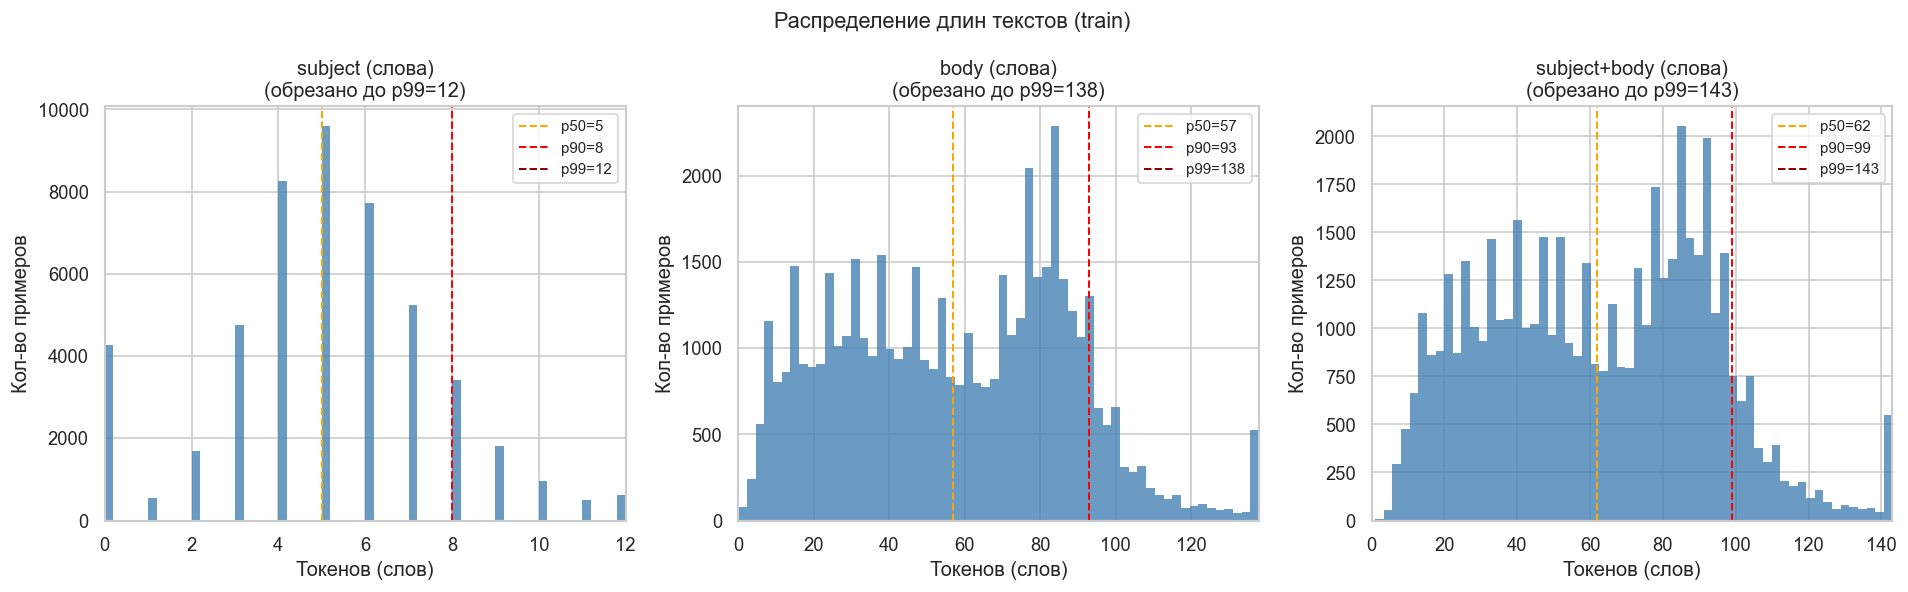

Сохранено: /Users/semenisaev/NLP_project_1/plots/text_lengths_train.png


In [13]:
# Гистограммы длин — train
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
field_labels = [('_len_subject', 'subject (слова)'),
                ('_len_body',    'body (слова)'),
                ('_len_total',   'subject+body (слова)')]

for ax, (col, label) in zip(axes, field_labels):
    data = df_train[col]
    # Обрезаем хвост на 99-м перцентиле для читаемости
    clip99 = int(np.percentile(data, 99))
    clipped = data.clip(upper=clip99)
    ax.hist(clipped, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    for p, color in [(50, 'orange'), (90, 'red'), (99, 'darkred')]:
        pv = int(np.percentile(data, p))
        ax.axvline(pv, color=color, linestyle='--', linewidth=1.2,
                   label=f'p{p}={pv}')
    ax.set_title(label)
    ax.set_xlabel('Токенов (слов)')
    ax.set_ylabel('Кол-во примеров')
    ax.legend(fontsize=9)
    if clip99 < int(np.percentile(data, 100)):
        ax.set_xlim(0, clip99)
        ax.set_title(label + f'\n(обрезано до p99={clip99})')

plt.suptitle('Распределение длин текстов (train)', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'text_lengths_train.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "text_lengths_train.png"}')

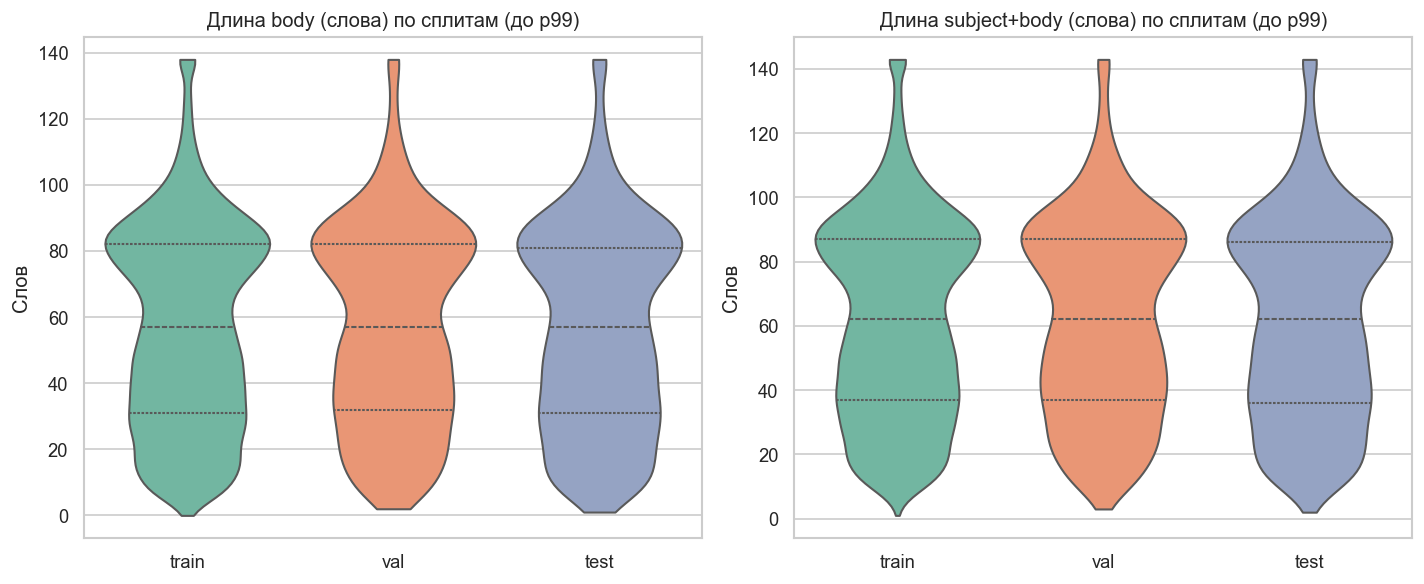

Сохранено: /Users/semenisaev/NLP_project_1/plots/text_lengths_violin.png


In [14]:
# Сравнение длин body по сплитам (box plot)
len_data = pd.concat([
    splits[name][['_len_body', '_len_total']].assign(split=name)
    for name in splits
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
                           ['_len_body', '_len_total'],
                           ['body (слова)', 'subject+body (слова)']):
    # Обрезаем до 99-го перцентиля для читаемости
    clip = int(len_data[col].quantile(0.99))
    plot_df = len_data[[col, 'split']].copy()
    plot_df[col] = plot_df[col].clip(upper=clip)
    sns.violinplot(data=plot_df, x='split', y=col, palette='Set2', ax=ax,
                   inner='quartile', cut=0)
    ax.set_title(f'Длина {title} по сплитам (до p99)')
    ax.set_ylabel('Слов')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'text_lengths_violin.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "text_lengths_violin.png"}')

## 8. Длины текстов по классам queue (топ-10)

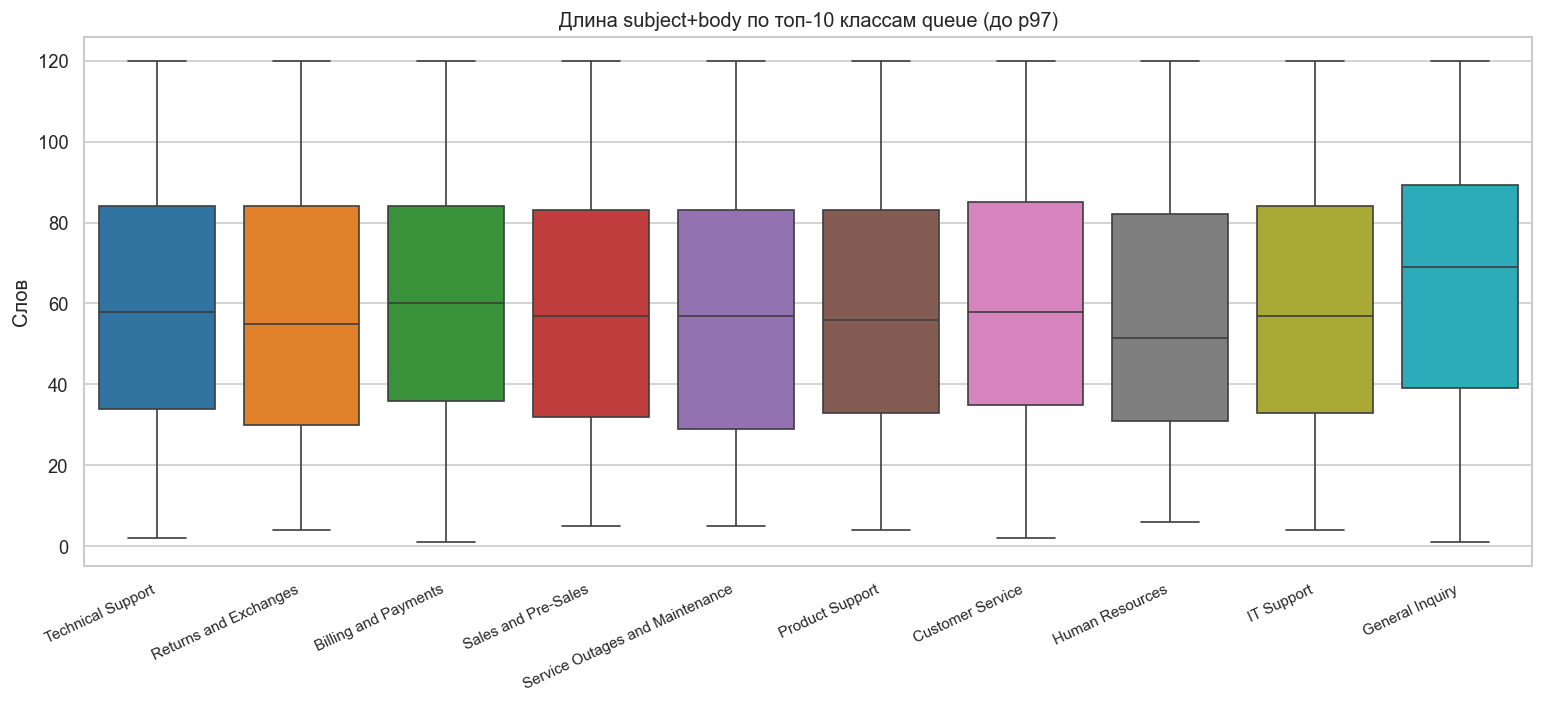

Сохранено: /Users/semenisaev/NLP_project_1/plots/text_len_by_queue.png


In [15]:
top10_queues = df_train['queue'].value_counts().head(10).index.tolist()
sub = df_train[df_train['queue'].isin(top10_queues)].copy()

fig, ax = plt.subplots(figsize=(13, 6))
clip = int(sub['_len_total'].quantile(0.97))
sub2 = sub.copy()
sub2['_len_total_clipped'] = sub2['_len_total'].clip(upper=clip)
sns.boxplot(data=sub2, x='queue', y='_len_total_clipped', palette='tab10', ax=ax)
ax.set_title('Длина subject+body по топ-10 классам queue (до p97)')
ax.set_ylabel('Слов')
ax.set_xlabel('')
plt.setp(ax.get_xticklabels(), rotation=25, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'text_len_by_queue.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Сохранено: {PLOTS_DIR / "text_len_by_queue.png"}')

## 9. Покрытие классов по сплитам

In [16]:
for target in ['queue', 'priority', 'type']:
    print(f'\n--- {target} ---')
    train_labels = set(df_train[target].astype(str).unique())
    for name, d in splits.items():
        labels = set(d[target].astype(str).unique())
        missing = sorted(train_labels - labels)
        print(f'  {name}: {len(labels)} классов | отсутствуют vs train: {len(missing)} → {missing[:5]}{"..." if len(missing) > 5 else ""}')


--- queue ---
  train: 52 классов | отсутствуют vs train: 0 → []
  val: 52 классов | отсутствуют vs train: 0 → []
  test: 52 классов | отсутствуют vs train: 0 → []

--- priority ---
  train: 5 классов | отсутствуют vs train: 0 → []
  val: 5 классов | отсутствуют vs train: 0 → []
  test: 5 классов | отсутствуют vs train: 0 → []

--- type ---
  train: 5 классов | отсутствуют vs train: 0 → []
  val: 5 классов | отсутствуют vs train: 0 → []
  test: 5 классов | отсутствуют vs train: 0 → []


## 10. Сводная сохранённых графиков

In [17]:
saved = sorted(PLOTS_DIR.glob('*.png'))
print(f'Сохранено {len(saved)} графиков в {PLOTS_DIR}:')
for p in saved:
    print(f'  {p.name}')

Сохранено 10 графиков в /Users/semenisaev/NLP_project_1/plots:
  nan_heatmap.png
  priority_splits.png
  priority_type_dist.png
  queue_imbalance.png
  queue_tail.png
  queue_top20.png
  text_len_by_queue.png
  text_lengths_train.png
  text_lengths_violin.png
  type_splits.png


## Итоги EDA

| Аспект | Вывод |
|--------|-------|
| **Размеры** | train 49 412 / val 6 176 / test 6 177 — стандартное ~80/10/10 |
| **queue** | 52 класса, сильный дисбаланс (~X раз топ vs хвост); нужен class_weight или over-sampling |
| **priority** | 5 классов, умеренный дисбаланс |
| **type** | 5 классов + Unknown; Unknown — результат fillna |
| **Тексты** | body существенно длиннее subject; большой разброс (p50 ≪ p99) — нужна обрезка при токенизации |
| **NaN** | body и subject могут содержать NaN — обязательна стратегия заполнения |
| **Утечки** | Межсплитовых текстовых дублей нет |
